# 08 Ordinary Differential Equations

# Calculate the period of a pendulum

## Physics:
$$\vec{F}=m\vec{a}$$ or $$\tau=I\alpha$$.

We then find the ordinary differential equation:
\begin{equation}
\ddot{\theta}=-\frac{g}{l}\sin{\theta} 
\end{equation}

which has the solution $$\theta=A\cos{\omega t}+B\sin{\omega t}, \omega=\sqrt{g/l}$$
## Numerics:  Analytical small angle approximation
We start with the simple pendulum; consisting of a string of length 63.5 cm.  We assume the small amplitude approximation, and the initial condition that at t=0 the pendulum is at $\theta_0=\pi/3$ and $\dot{\theta}=0$.  Then 
\begin{align}
\theta&=\theta_0\cos{\omega t}\\
\omega&=\sqrt{g/l}\\
\end{align}

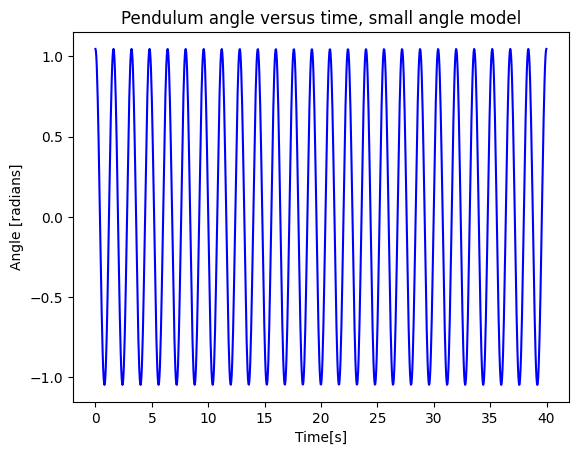

In [1]:
import numpy as np
import matplotlib.pyplot as plt
 
theta_0=np.pi/3
l=0.635 #length of pendulum, meters
g=9.8 # acceleration of gravity on Earth's surface, meters/s**2
omega=np.sqrt(g/l)
T=2*np.pi/omega  #  period, seconds

nsteps0=1000
t = np.linspace(0.0, 25.0*T, nsteps0)
y0=theta_0*np.cos(omega*t)

plt.plot(t, y0, 'b')
plt.title('Pendulum angle versus time, small angle model')
plt.xlabel('Time[s]')
plt.ylabel('Angle [radians]')
plt.show()

## Without the small angle approximation: simple finite difference solution

This is called "Euler integration" in NR, chapter 17.  It is good to read chapter 17 at this point.  
The original equation for the pendulum is:
\begin{equation}
\ddot{\theta}=-\frac{g}{l}\sin{\theta} 
\end{equation}

We write this second order equation as coupled first order equations:
\begin{equation}
\frac{d}{dt}\left(
\begin{array}{c}
\omega\\
\theta\\
\end{array}
\right)=
\left(
\begin{array}{c}
-\frac{g}{l}\sin{\theta}\\
\omega\\
\end{array}\right)
\end{equation}

Expanding the derivatives in terms of $\Delta$ we have
\begin{equation}
\left(
\begin{array}{c}
\frac{\omega(t+\Delta)-\omega(t)}{\Delta}\\
\frac{\theta(t+\Delta)-\theta(t)}{\Delta}\\
\end{array}
\right)=
\left(
\begin{array}{c}
-\frac{g}{l}\sin{\theta}\\
\omega\\
\end{array}\right)
\end{equation}

This ends up giving us a recursion relationship:
\begin{equation}
\left(
\begin{array}{c}
\omega(t+\Delta)\\
\theta(t+\Delta)\\
\end{array}
\right)=
\left(
\begin{array}{c}
-\Delta\frac{g}{l}\sin{\theta(t)}+\omega(t)\\
\Delta\omega(t)+\theta(t)\\
\end{array}\right)
\end{equation}

We write a little Python loop to calculate $\omega$ and $\theta$ using this equation:

Number of steps =100000 and size of steps=0.000400 between 0 and 39.984687 s


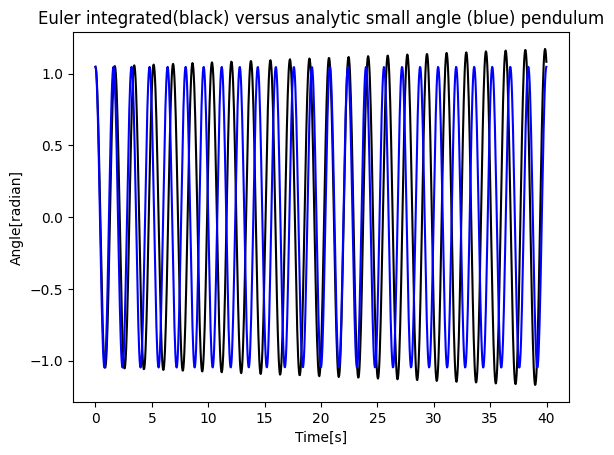

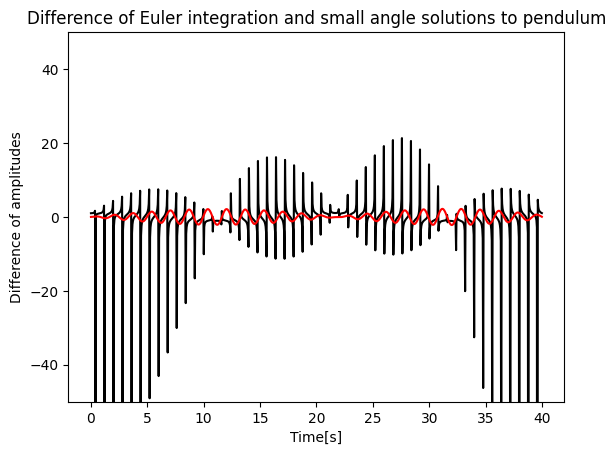

In [2]:
factor=100
nsteps=nsteps0*factor
t2=np.linspace(0,25*T,nsteps)
x=np.zeros(2*len(t2)).reshape(len(t2),2)
Delta=t2[1]
print('Number of steps =%d and size of steps=%f between 0 and %f s'%(len(t2),Delta,25*T))


# we will use the 0-row for theta, and the 1-row for omega
x[0,1]=0  #initial condition is pendulum at rest
x[0,0]=theta_0 #initial condition 
for i in np.arange(0,len(t2)-1):
    x[i+1,1]=-Delta*g/l*np.sin(x[i,0])+x[i,1]
    x[i+1,0]=Delta*x[i,1]+x[i,0]

# It isn't straightforward to operate on the "whole array", like we are used to doing in python.  Why is that?
    
y=x[::factor,0]
r=y/y0

plt.plot(t,y,'k')
plt.plot(t, y0, 'b')
plt.title('Euler integrated(black) versus analytic small angle (blue) pendulum')
plt.xlabel('Time[s]')
plt.ylabel('Angle[radian]')
plt.show()

plt.plot(t,r,'k')
plt.plot(t,y-y0,'red')
plt.title('Difference of Euler integration and small angle solutions to pendulum')
plt.xlabel('Time[s]')
plt.ylabel('Difference of amplitudes')
plt.ylim(-50,50)
plt.show()



Number of steps =1000000 and size of steps=0.000040 between 0 and 39.984687 s


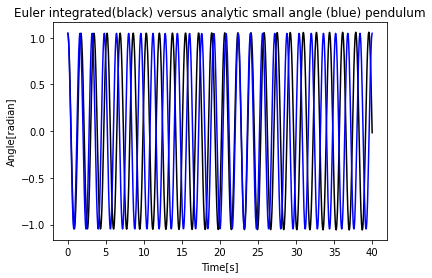

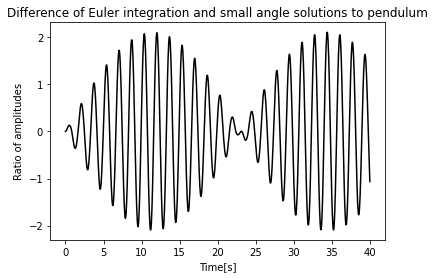

In [4]:
factor=1000
nsteps=nsteps0*factor
t2=np.linspace(0,25*T,nsteps)
x=np.zeros(2*len(t2)).reshape(len(t2),2)
Delta=t2[1]
print('Number of steps =%d and size of steps=%f between 0 and %f s'%(len(t2),Delta,25*T))

# we will use the 0-row for theta, and the 1-row for omega
x[0,1]=0  #initial condition is pendulum at rest
x[0,0]=theta_0 #initial condition 
for i in np.arange(0,len(t2)-1):
    x[i+1,1]=-Delta*g/l*np.sin(x[i,0])+x[i,1]
    x[i+1,0]=Delta*x[i,1]+x[i,0]
y=x[::factor,0]
r=y-y0
plt.plot(t,y,'k')
plt.plot(t, y0, 'b')
plt.title('Euler integrated(black) versus analytic small angle (blue) pendulum')
plt.xlabel('Time[s]')
plt.ylabel('Angle[radian]')
plt.show()
plt.plot(t,r,'k')
plt.title('Difference of Euler integration and small angle solutions to pendulum')
plt.xlabel('Time[s]')
plt.ylabel('Ratio of amplitudes')
plt.show()



Number of steps =10000000 and size of steps=0.000004 between 0 and 39.984687 s


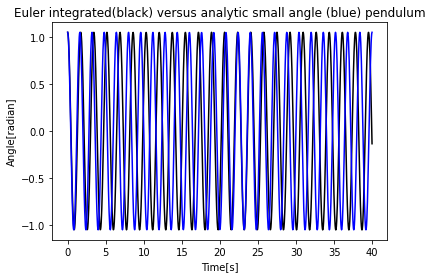

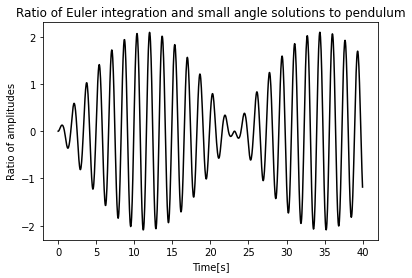

In [4]:
#multiply the number of steps by 10
factor=10000
nsteps=nsteps0*factor
t2=np.linspace(0,25*T,nsteps)
x=np.zeros(2*len(t2)).reshape(len(t2),2)
Delta=t2[1]
print('Number of steps =%d and size of steps=%f between 0 and %f s'%(len(t2),Delta,25*T))

# we will use the 0-row for theta, and the 1-row for omega
x[0,1]=0  #initial condition is pendulum at rest
x[0,0]=theta_0 #initial condition 
for i in np.arange(0,len(t2)-1):
    x[i+1,1]=-Delta*g/l*np.sin(x[i,0])+x[i,1]
    x[i+1,0]=Delta*x[i,1]+x[i,0]
y=x[::factor,0]
r=y-y0
plt.plot(t,y,'k')
plt.plot(t, y0, 'b')
plt.title('Euler integrated(black) versus analytic small angle (blue) pendulum')
plt.xlabel('Time[s]')
plt.ylabel('Angle[radian]')
plt.show()
plt.plot(t,r,'k')
plt.title('Ratio of Euler integration and small angle solutions to pendulum')
plt.xlabel('Time[s]')
plt.ylabel('Ratio of amplitudes')
plt.show()



# Verification

For this code, what can we do?  
1.  Do the second numerical derivative and compare it to the equation (ie.  substitute back in)
2.  Do time reversal, and see if we come back to the starting point.
3.  Add an explicit calculation of the total energy, and see that it is constant

Why do we do all three rather than just one?



We start with doing the second order numerical derivative:
\begin{equation}
\ddot{\theta}=\frac{g}{l}\sin{\theta}=\frac{1}{h}\left(\frac{\theta(t+h)-\theta(t)}{h}-\frac{\theta(t)-\theta(t-h)}{h}\right)=\frac{\theta(t+h)+\theta(t-h)-2\theta(t)}{h^2}
\end{equation}


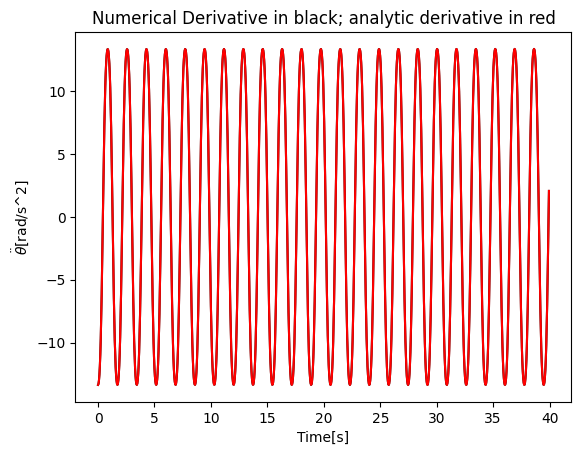

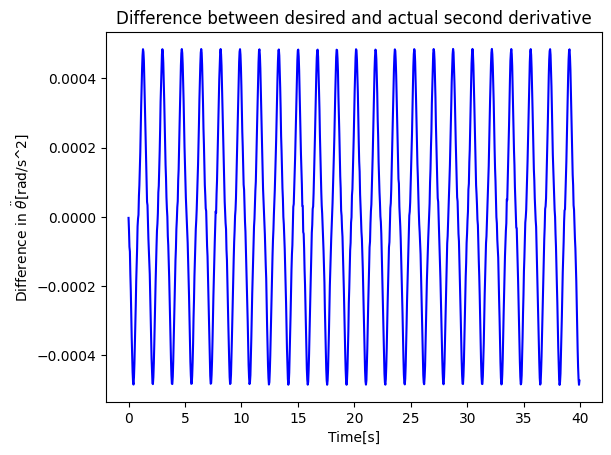

In [9]:
thetaOfT=x[1:-1,0]
thetaTPlusH=x[2:,0]
thetaTMinusH=x[:-2,0]
h=Delta
# can't use our normal derivative because we don't actually have a continuous function right now!
thetaDotDot=(1/h**2)*(thetaTPlusH+thetaTMinusH-2*thetaOfT)
plt.plot(t2[1:-1:factor],thetaDotDot[::factor],'k')
plt.plot(t2[1:-1:factor],-g/l*np.sin(thetaOfT[1:-1:factor]),'r')
plt.title("Numerical Derivative in black; analytic derivative in red")
plt.xlabel("Time[s]")
plt.ylabel(r'$\ddot\theta$[rad/s^2]')
plt.show()

diff=thetaDotDot[::factor]+g/l*np.sin(thetaOfT[1:-1:factor])
plt.plot(t2[1:-1:factor],diff,'b')
plt.title("Difference between desired and actual second derivative")
plt.xlabel("Time[s]")
plt.ylabel(r'Difference in $\ddot\theta$[rad/s^2]')
plt.show()


This would indicate that our precision is about 0.0004/10 or 4 e-5.  It needs to be a bit better than this because theta is also an output of the calculation- that is we are checking the derivative of $\theta$, which is $\omega$!  

To time reverse we set our initial values (theta0, phi0) to the final value, and make the derivative be negative the old derivative. 

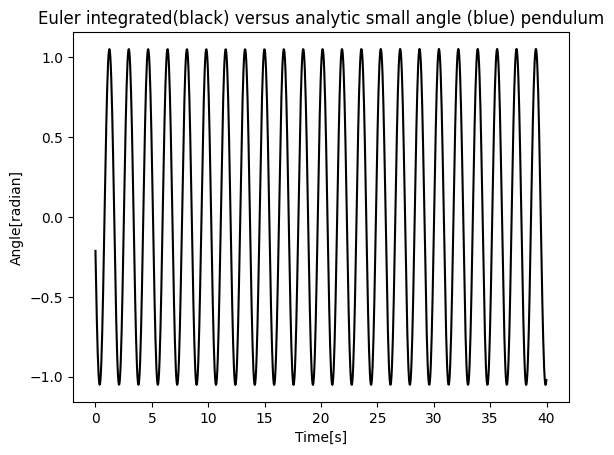

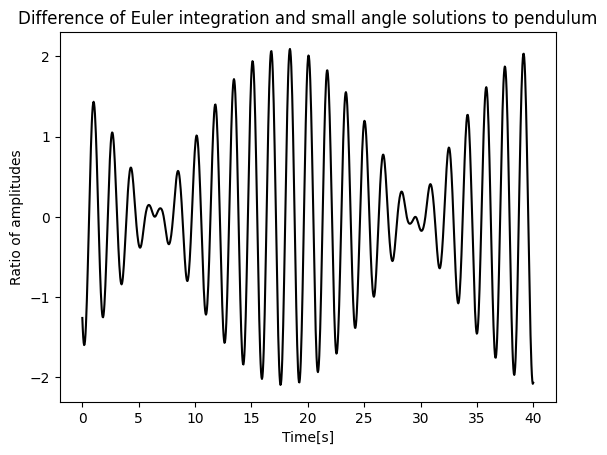

Final theta=-0.973643 omega=-1.432113
Original theta0=1.047198 omega0=0.000000
Fractional Difference= -0.01286507243101656


In [12]:
x[0,1]=x[-1,1]  #initial condition is pendulum at rest
x[0,0]=x[-1,0] #initial condition 
for i in np.arange(0,len(t2)-1):
    x[i+1,1]=Delta*g/l*np.sin(x[i,0])+x[i,1]
    x[i+1,0]=-Delta*x[i,1]+x[i,0]
y=x[::factor,0]
r=y-y0
plt.plot(t,y,'k')
plt.title('Euler integrated(black) versus analytic small angle (blue) pendulum')
plt.xlabel('Time[s]')
plt.ylabel('Angle[radian]')
plt.show()
plt.plot(t,r,'k')
plt.title('Difference of Euler integration and small angle solutions to pendulum')
plt.xlabel('Time[s]')
plt.ylabel('Ratio of amplitudes')
plt.show()


print('Final theta=%f omega=%f'%(x[-1,0],x[-1,1]))
print('Original theta0=%f omega0=%f'%(theta_0,0))
print('Fractional Difference=',(x[-1,0]-theta_0)/(50*np.pi))


Notice that this also says we have something like 2e-3.  


The total energy is $E=1/2 mv^2+mgh=1/2ml^2\omega^2-mgl\cos\theta$.


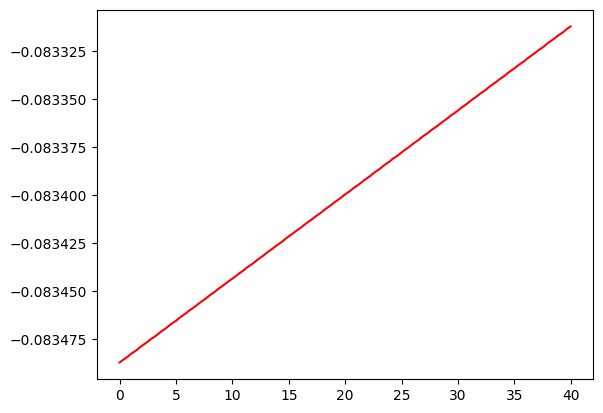

Energy is [-0.0834871  -0.0834869  -0.08348671 -0.08348653 -0.08348635 -0.08348619
 -0.08348603 -0.08348587 -0.08348572 -0.08348556 -0.0834854  -0.08348525
 -0.08348509 -0.08348493 -0.08348477 -0.08348461 -0.08348443 -0.08348425
 -0.08348406 -0.08348386 -0.08348365 -0.08348344 -0.08348324 -0.08348304
 -0.08348286 -0.08348268 -0.08348251 -0.08348235 -0.08348219 -0.08348204
 -0.08348188 -0.08348172 -0.08348157 -0.08348141 -0.08348125 -0.0834811
 -0.08348093 -0.08348076 -0.08348058 -0.0834804  -0.0834802  -0.08347999
 -0.08347978 -0.08347958 -0.08347938 -0.08347919 -0.08347901 -0.08347884
 -0.08347867 -0.08347851 -0.08347836 -0.0834782  -0.08347804 -0.08347789
 -0.08347773 -0.08347757 -0.08347742 -0.08347726 -0.08347709 -0.08347692
 -0.08347673 -0.08347654 -0.08347634 -0.08347613 -0.08347592 -0.08347572
 -0.08347552 -0.08347534 -0.08347516 -0.08347499 -0.08347483 -0.08347467
 -0.08347452 -0.08347436 -0.08347421 -0.08347405 -0.08347389 -0.08347374
 -0.08347358 -0.08347341 -0.08347324 -0.08

In [14]:

m=0.027
Energy=(0.5*m*l**2)*x[::factor,1]**2-(m*g*l)*np.cos(x[::factor,0])
plt.plot(t,Energy,'r')
plt.show()
print('Energy is', Energy)



But also note that we already have a physics result-- the large angle pendulum has a longer period than the "small angle" approximation by about 1 cycle in 23- or about 4-5% in this case.  That makes sense because the acceleration is smaller.  Of course, this will depend on the amplitude, and as the amplitude drops the approximation will get closer to reality.    